# Index

1. LLaMA and other versions
2. Mistral and other versions



# Reference
- LLaMA and LLama-2: 
    - video: https://www.youtube.com/watch?v=Mn_9W1nCFLo
    - blog: https://cameronrwolfe.substack.com/p/llama-2-from-the-ground-up
    
- Mistral: 
    - video: https://www.youtube.com/watch?v=UiX8K-xBUpE

- MoE:
    - https://www.youtube.com/watch?v=0QQlYR1r6pQ
    - https://www.youtube.com/watch?v=sOPDGQjFcuM


LLM Architectures Comparison:
1. https://magazine.sebastianraschka.com/p/the-big-llm-architecture-comparison


In [10]:
import os
from PIL import Image
from IPython.display import SVG, display, HTML  # Added HTML here
notebook_dir = os.path.abspath('')

def displayImage(img_path):
    try:
        with open(img_path, "r", encoding="utf-8") as f:
            svg_content = f.read()

        # HTML is now defined and will work correctly
        display(HTML(f"""
        <div style="background-color:#1e1e1e; padding:20px;">
            <div style="width:1000px;">
                {svg_content}
            </div>
        </div>
        """))

    except FileNotFoundError:
        print(f"Error: Could not find image at {img_path}")


def displayPNGImage(img_path):
    try:
        img = Image.open(img_path)
        display(img)
    except FileNotFoundError:
        print(f"Error: Could not find image at {img_path}")


# Llama Architecture

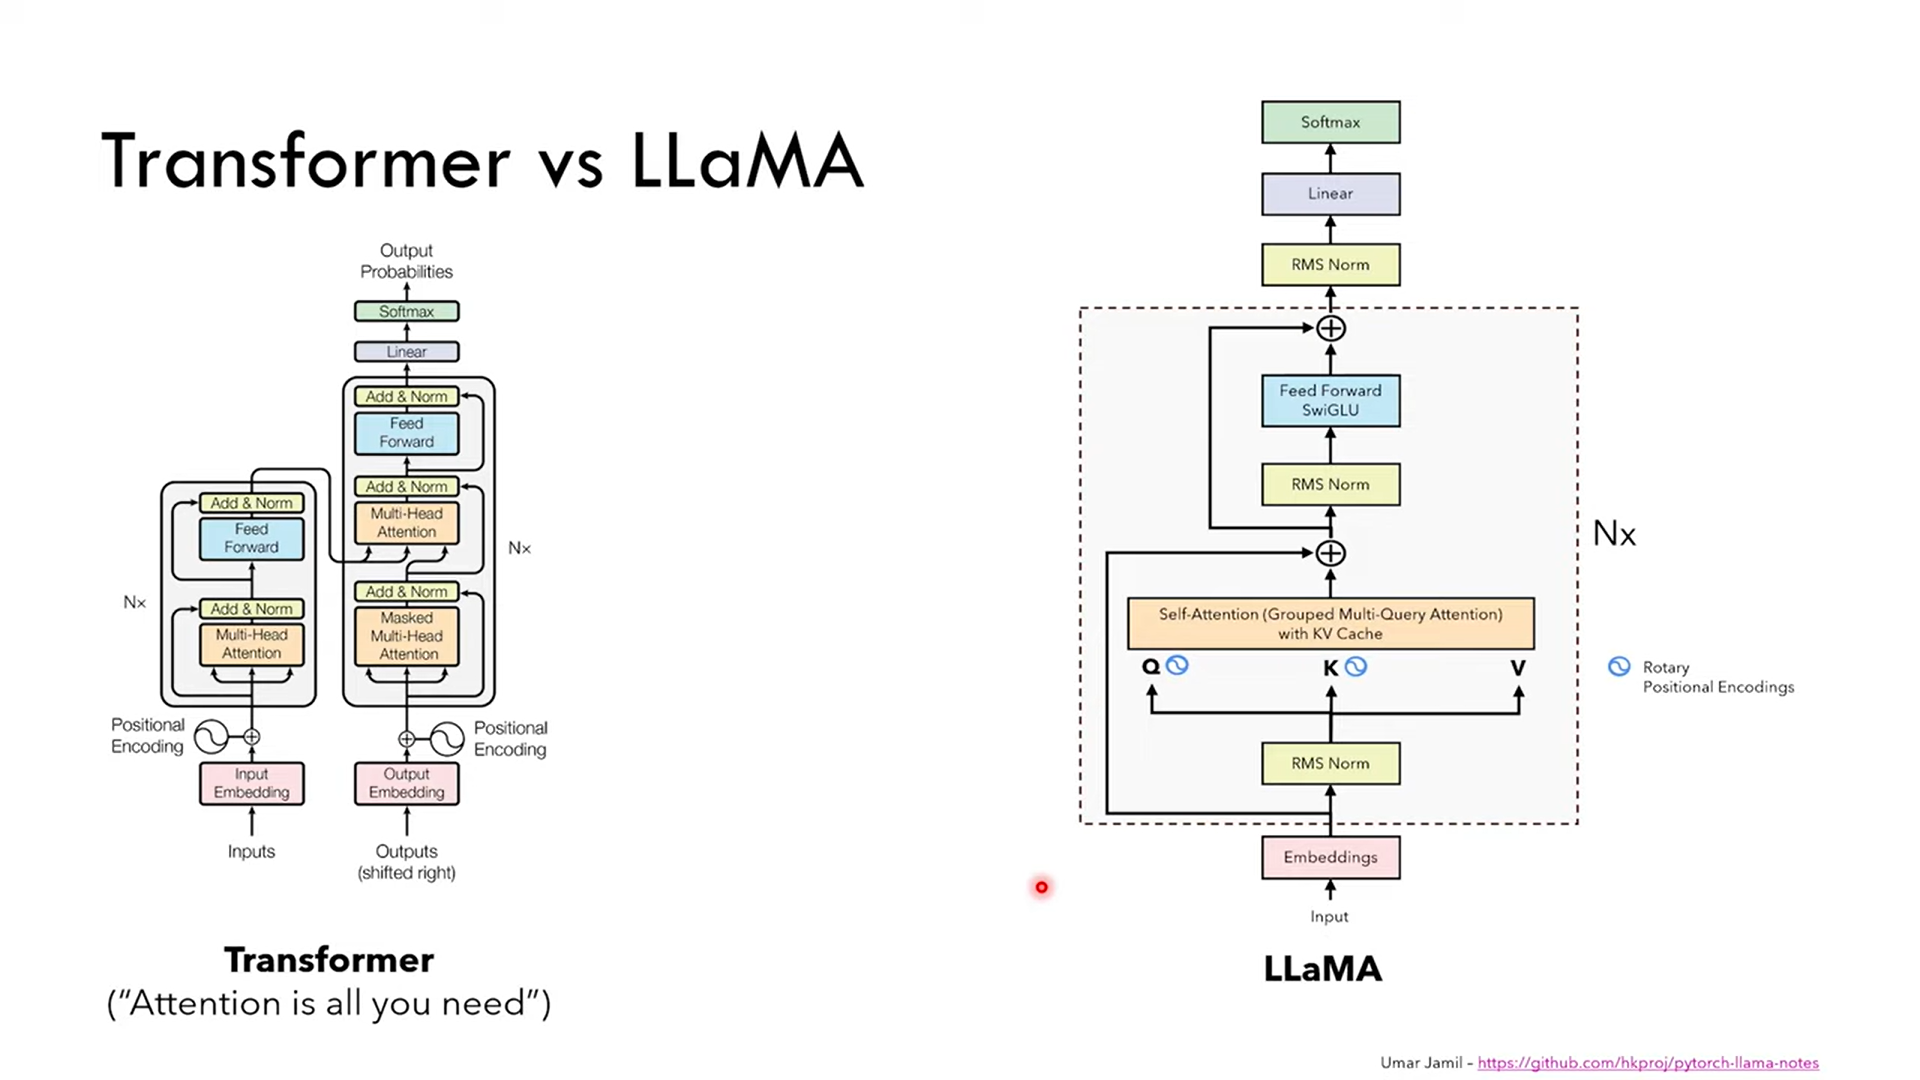

In [11]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\transformer_vs_llama.png")
displayPNGImage(img_path)

# RMSNorm — Root Mean Square Layer Normalization

> **Source:** Zhang & Sennrich, NeurIPS 2019
> **The big picture:** Deep networks suffer from a problem called internal covariate shift — the distribution of each layer's inputs keeps changing as the weights of earlier layers update, which destabilizes gradient flow and slows convergence. Normalization layers were introduced to fix this. BatchNorm, LayerNorm, and RMSNorm are three generations of solutions, each addressing the previous one's shortcomings.

---

## The Problem: Internal Covariate Shift

A standard feed-forward layer computes:

$$a_i = \sum_{j=1}^{m} w_{ij}\, x_j, \qquad y_i = f(a_i + b_i)$$

**Where:**
- $x_j$ — the $j$-th element of the input vector $\mathbf{x} \in \mathbb{R}^m$
- $w_{ij}$ — the weight connecting input $j$ to output neuron $i$
- $a_i$ — the weighted sum of inputs arriving at neuron $i$ (called the **summed input**). This is the quantity that normalization targets
- $b_i$ — the bias scalar for neuron $i$
- $f(\cdot)$ — a non-linear activation function
- $y_i$ — the final output of neuron $i$

As training progresses, weights $w_{ij}$ of earlier layers keep changing. This shifts the distribution of $\mathbf{x}$ seen by later layers — even if those later layers have not changed at all. The layer now receives inputs with a different scale and mean than it was trained on, destabilizing its gradients and slowing convergence. This is **internal covariate shift**.

Normalization fixes this by controlling the distribution of the summed inputs $a_i$ so that they stay in a stable range regardless of what earlier layers are doing.

---

## Generation 1 — Batch Normalization (High Level)

**Introduced:** Ioffe & Szegedy, 2015

BatchNorm normalizes each feature $j$ across the batch dimension. For a batch of $B$ samples:

$$\mu_B = \frac{1}{B}\sum_{b=1}^{B} x_b, \qquad \sigma_B^2 = \frac{1}{B}\sum_{b=1}^{B}(x_b - \mu_B)^2$$

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y = \gamma\,\hat{x} + \beta$$

**Where:** $\mu_B$ is the batch mean, $\sigma_B^2$ is the batch variance, $\epsilon$ is a small constant for numerical stability, $\gamma$ is a learned scale, and $\beta$ is a learned shift.

### Why BatchNorm fails for LLMs

**Problem 1 — Batch dependency at inference:** $\mu_B$ and $\sigma_B^2$ are estimated from the batch. When generating tokens one at a time (batch size = 1), there is no valid batch to compute statistics from — you must use running averages collected during training, which are approximations and fail on out-of-distribution inputs.

**Problem 2 — Variable sequence lengths:** In NLP, sequences in a batch have different lengths. Normalizing across a batch of variable-length sequences mixes statistics across unrelated sentences — token 5 of sentence A contaminates the normalization of token 5 of sentence B.

**Problem 3 — Sequential incompatibility:** BatchNorm requires seeing all batch elements simultaneously, which is impossible during autoregressive generation.

BatchNorm is essentially unusable for transformer-based LLMs.

---

## Generation 2 — Layer Normalization (High Level)

**Introduced:** Ba et al., 2016

LayerNorm fixes BatchNorm's batch dependency by computing statistics across the **feature dimension** of a single sample, not across the batch. For a single token's hidden state $\mathbf{a} \in \mathbb{R}^n$ (the summed inputs to one layer):

$$\mu = \frac{1}{n}\sum_{i=1}^{n} a_i, \qquad \sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(a_i - \mu)^2$$

$$\bar{a}_i = \frac{a_i - \mu}{\sigma}\, g_i, \qquad y_i = f(\bar{a}_i + b_i)$$

**Where:**
- $a_i$ — the $i$-th summed input to a neuron in this layer (same as defined above — this is what gets normalized)
- $n$ — the number of neurons in the layer (hidden dimension size)
- $\mu$ — the mean of all summed inputs within this single layer, for this single token
- $\sigma^2$ — the variance of those summed inputs
- $\bar{a}_i$ — the normalized summed input for neuron $i$
- $g_i$ — the learned gain (scale) parameter for neuron $i$, equivalent to $\gamma$ in BatchNorm notation
- $b_i$ — the learned bias for neuron $i$, equivalent to $\beta$

Statistics are computed per-token, per-layer — completely independent of other tokens or batch elements.

### The two invariance properties LayerNorm provides

**Re-centering invariance:** Subtracting $\mu$ makes the output invariant to shifts in inputs or weights. If you add a constant $\delta$ to all inputs $a_i$, the mean shifts by $\delta$ but $a_i - \mu$ is unchanged — the normalized output is identical.

**Re-scaling invariance:** Dividing by $\sigma$ makes the output invariant to scaling of inputs or weights. If you multiply all inputs by a constant $\alpha$, both $a_i$ and $\sigma$ scale by $\alpha$ — the ratio is unchanged.

### Why LayerNorm still has overhead

LayerNorm computes both mean and variance. On a hidden state of dimension $n$:
- **Pass 1:** sum all $a_i$ → compute $\mu$ (requires seeing all values first)
- **Pass 2:** subtract $\mu$, square, sum → compute $\sigma^2$ (depends on $\mu$, so cannot start until Pass 1 is done)
- **Pass 3:** normalize

These passes create a strict **dependency chain** — variance cannot be computed until the mean is known. On parallel hardware like GPUs, this forces synchronization between passes, creating a bottleneck that grows with model size and depth. As shown in the RMSNorm paper's experiments on a GRU-based model: while LayerNorm reaches loss 5.4 in the same number of training steps as baseline (good), it only reaches 5.9 in the same wall-clock time — the computational overhead erodes the training speed gains.

---

## Generation 3 — RMSNorm

**Introduced:** Zhang & Sennrich, NeurIPS 2019

### The Hypothesis

The paper makes a specific, testable claim:

> *"Re-centering invariance in LayerNorm is dispensable. The success of LayerNorm comes from re-scaling invariance, not from mean subtraction."*

Their argument: mean normalization (subtracting $\mu$) does not reduce the variance of hidden states or model gradients. What actually stabilizes training is keeping the **magnitude** (scale) of activations consistent — and that is entirely handled by dividing by $\sigma$. The mean subtraction is doing almost no useful work.

If true, you can drop the mean computation entirely and just normalize by a simpler measure of magnitude — the root mean square.

### The Formula

Given the unnormalized summed inputs $\mathbf{a} \in \mathbb{R}^n$ to a layer, RMSNorm computes:

$$\text{RMS}(\mathbf{a}) = \sqrt{\frac{1}{n}\sum_{i=1}^{n} a_i^2}$$

Then normalizes and rescales:

$$\bar{a}_i = \frac{a_i}{\text{RMS}(\mathbf{a})}\, g_i$$

Written in full:

$$\text{RMSNorm}(\mathbf{a})_i = \frac{a_i}{\sqrt{\dfrac{1}{n}\displaystyle\sum_{k=1}^{n} a_k^2 + \epsilon}}\cdot g_i$$

**Where every symbol is defined:**
- $\mathbf{a} \in \mathbb{R}^n$ — the vector of summed inputs to all $n$ neurons in this layer, for one token. This is exactly the same $a_i$ as in the LayerNorm equations above — the weighted sum arriving at each neuron before activation
- $a_i$ — the summed input to the $i$-th neuron specifically
- $a_k$ — the summed input to the $k$-th neuron; the index $k$ is used inside the sum to avoid confusion with the output index $i$
- $n$ — total number of neurons in this layer (hidden dimension, e.g. 4096 in LLaMA 2 7B, 7168 in LLaMA 3)
- $\text{RMS}(\mathbf{a})$ — the root mean square of the entire vector $\mathbf{a}$: take each element, square it, average the squares, take the square root. This is a single scalar that measures the typical magnitude of the vector
- $\epsilon$ — a small positive constant (e.g. $10^{-6}$) added inside the square root purely for numerical stability. When $\mathbf{a} \approx \mathbf{0}$, without $\epsilon$ you would divide by zero
- $g_i$ — the learned gain (scale) parameter for neuron $i$, initialized to 1. This lets the model rescale the normalized output on a per-neuron basis. It is the only learned parameter in RMSNorm — there is no bias term
- $\bar{a}_i$ — the final normalized, rescaled output for neuron $i$, which then feeds into the activation function

### What Is RMS and Why Is It the Right Quantity

The **root mean square** of a vector measures its typical element magnitude:

$$\text{RMS}(\mathbf{a}) = \sqrt{\frac{1}{n}\sum_{i=1}^n a_i^2} = \frac{\|\mathbf{a}\|_2}{\sqrt{n}}$$

It is the Euclidean (L2) norm of the vector, scaled down by $\sqrt{n}$.

Compare to **standard deviation** used in LayerNorm:

$$\sigma(\mathbf{a}) = \sqrt{\frac{1}{n}\sum_{i=1}^n (a_i - \mu)^2}$$

The only difference: standard deviation measures spread around the mean, while RMS measures magnitude around zero. When $\mu \approx 0$ (which is common in deep networks due to symmetric weight initialization and the zero-mean nature of residual connections), these two are nearly equal:

$$\mu \approx 0 \implies (a_i - \mu)^2 \approx a_i^2 \implies \sigma(\mathbf{a}) \approx \text{RMS}(\mathbf{a})$$

This is the empirical justification: in practice, the mean of summed inputs in deep transformers is close to zero at most layers, so the mean subtraction step in LayerNorm is essentially a no-op — it is subtracting a quantity that is nearly zero. RMSNorm simply acknowledges this and removes the computation entirely.

### What Is Removed Compared to LayerNorm

| Operation | LayerNorm | RMSNorm |
|---|---|---|
| Compute mean $\mu = \frac{1}{n}\sum a_i$ | Yes — 1st pass | **No** |
| Subtract mean: $a_i - \mu$ | Yes | **No** |
| Compute variance $\sigma^2$ | Yes — 2nd pass | **No** |
| Divide by scale: $a_i / \sigma$ | Yes | **No — divides by RMS instead** |
| Learned scale $g_i$ per neuron | Yes | Yes |
| Learned bias $b_i$ per neuron | Yes | **No** |

RMSNorm removes: mean computation, mean subtraction, variance computation, and the bias term. It keeps only: the sum-of-squares, the square root, the division, and the learned scale $g_i$.

### Why Removing $b_i$ (Bias) Also Makes Sense

The bias $b_i$ in LayerNorm is the $\beta$ that shifts the normalized output. Ablation studies (including in the RMSNorm paper) show that removing $b_i$ has near-zero effect on model quality. The reason: the bias term is trying to re-introduce a mean shift after normalization has just removed it. This is redundant — the next layer's own weight matrix can absorb any needed constant offset. Keeping $b_i$ doubles the number of normalization parameters without contributing to performance.

---

## The Computational Advantage — Why It Is Faster

LayerNorm creates a **dependency chain**:
```
1. Read all aᵢ → compute μ               (cannot start step 2 until step 1 done)
2. Read all aᵢ again, subtract μ → σ²    (cannot start step 3 until step 2 done)
3. Divide each aᵢ by σ, multiply by gᵢ
```

RMSNorm collapses this to a **single pass**:
```
1. Read all aᵢ → compute sum of squares → RMS   (single pass, no dependency)
2. Divide each aᵢ by RMS, multiply by gᵢ
```

By eliminating the mean, which creates the dependency between steps 1 and 2, RMSNorm removes the synchronization barrier on GPU. All elements $a_i^2$ can be accumulated in parallel without waiting for a mean to be computed first.

**Measured speedup from the paper:** 7% to 64% reduction in running time depending on the model architecture. Larger improvements on deeper models with many normalization layers (RNNs in particular) and hardware setups where memory bandwidth is the bottleneck.

---

## Partial RMSNorm (pRMSNorm)

The paper also proposes an extension: since neurons in one layer often have an approximately i.i.d. structure, you do not need all $n$ values to get a good estimate of the RMS. You can estimate it from just the first $p\%$ of the summed inputs:

$$\text{RMS}_p(\mathbf{a}) = \sqrt{\frac{1}{m}\sum_{i=1}^{m} a_i^2}, \quad m = \lfloor p\% \cdot n \rfloor$$

Then normalize all $n$ neurons using this partial estimate. For example, with $p = 6.25\%$ on a hidden dimension of 1024, you compute RMS from only 64 values instead of 1024. The paper shows this achieves competitive performance while further reducing computation — though with a practical caveat: too small an $m$ (e.g. fewer than ~8 values) causes gradient instability and training can diverge.

---

## Re-scaling Invariance — What It Means Formally

RMSNorm is **re-scaling invariant**: if you multiply all inputs $\mathbf{a}$ by a scalar $\alpha$, or multiply all weights $\mathbf{w}$ by $\alpha$, the output is unchanged.

**Proof for input scaling:** Replace $a_i$ with $\alpha a_i$:

$$\text{RMS}(\alpha\mathbf{a}) = \sqrt{\frac{1}{n}\sum_{i=1}^n (\alpha a_i)^2} = |\alpha|\,\text{RMS}(\mathbf{a})$$

$$\frac{\alpha a_i}{\text{RMS}(\alpha\mathbf{a})} = \frac{\alpha a_i}{|\alpha|\,\text{RMS}(\mathbf{a})} = \frac{a_i}{\text{RMS}(\mathbf{a})} \cdot \text{sign}(\alpha)$$

For positive $\alpha$ (which is the relevant case since RMS normalizes magnitude), the output is identical. This is what makes RMSNorm robust to weight initialization scale and learning rate — even if weights drift in magnitude, the normalization corrects for it automatically.

RMSNorm does **not** have re-centering invariance — if you shift all inputs by a constant $\delta$, the RMS changes and the output changes. This is the property that was sacrificed. The paper's argument is that this property was not providing real benefit in practice.

---

## Pre-Norm Placement in Modern Transformers

Where normalization is placed in the transformer block matters independently of which normalization you choose.

**Post-Norm (original Transformer, 2017):**
$$\text{output} = \text{Norm}(\mathbf{x} + \text{Sublayer}(\mathbf{x}))$$

Gradients must flow back through the normalization layer. In deep models this causes gradient vanishing and requires careful warmup schedules.

**Pre-Norm (modern standard):**
$$\text{output} = \mathbf{x} + \text{Sublayer}(\text{Norm}(\mathbf{x}))$$

The residual path $\mathbf{x} + (\ldots)$ is clean — gradients flow directly through the addition without passing through normalization. Training is more stable, less sensitive to learning rate choice, and works without warmup.

Modern LLMs use **Pre-RMSNorm** — applied before each attention block and each feed-forward block:

```
x ──► RMSNorm ──► Self-Attention ──► + ──► h
│                                    │
└────────────────────────────────────┘  (residual)

h ──► RMSNorm ──► Feed-Forward ──► + ──► output
│                                   │
└───────────────────────────────────┘  (residual)
```

Two RMSNorm operations per transformer block, both on the input before each sublayer.

---

## Summary

| | BatchNorm | LayerNorm | RMSNorm |
|---|---|---|---|
| Normalizes over | Batch dimension | Feature dimension | Feature dimension |
| Subtracts mean | Yes | Yes | **No** |
| Divides by | Std deviation $\sigma$ | Std deviation $\sigma$ | **RMS** |
| Learned scale $g_i$ | Yes ($\gamma$) | Yes ($g$) | Yes ($g$) |
| Learned bias | Yes ($\beta$) | Yes ($b$) | **No** |
| Batch size dependency | Yes | No | No |
| Number of passes | 2+ | 2+ | **1** |
| Speed vs LayerNorm | — | baseline | **7–64% faster** |
| Re-centering invariant | Yes | Yes | **No** |
| Re-scaling invariant | Yes | Yes | Yes |
| Used in modern LLMs | No | GPT-2, BERT | **LLaMA, Mistral, Qwen, DeepSeek** |

---

## Key Takeaway

RMSNorm is not just a faster version of LayerNorm — it is a principled simplification based on a specific hypothesis: **re-centering invariance is not what makes normalization work; re-scaling invariance is**. The hypothesis is supported both theoretically (mean of summed inputs is close to zero in deep nets) and empirically (comparable or better performance at 7–64% less compute). The result is a normalization that is simpler, faster, and equally effective — which is why it has become the default in every major modern LLM.

# SwiGLU Activation Function

> **Builds on:** Feed-forward layers in transformers, ReLU, GELU
> **Problem it solves:** Standard FFN activations (ReLU, GELU) apply a nonlinearity uniformly to all dimensions. There is no mechanism for the network to selectively suppress or amplify specific dimensions based on the input content. GLU and SwiGLU introduce gating — the network learns both *what to say* and *whether to say it*.

---

## Why Activation Functions Matter in FFN Layers

Every transformer block has a feed-forward network (FFN) after attention:

$$\text{FFN}(\mathbf{x}) = \text{activation}(\mathbf{x}W_1) \cdot W_2$$

**Where:**
- $\mathbf{x} \in \mathbb{R}^d$ — the input token representation (output of attention + residual)
- $W_1 \in \mathbb{R}^{d \times d_{ff}}$ — up-projection matrix, expands dimension from $d$ to $d_{ff}$ (typically $d_{ff} = 4d$)
- $W_2 \in \mathbb{R}^{d_{ff} \times d}$ — down-projection matrix, compresses back to $d$
- $\text{activation}$ — the only nonlinearity in this block; without it, the two matrix multiplications collapse into one linear transformation

The original transformer used **ReLU**: $\max(0, x)$. Simple and fast, but has a known failure mode — dead neurons. Any unit receiving a consistently negative input produces exactly zero output and zero gradient, so its weights stop updating permanently.

**GELU** improved on this with a smooth approximation: $x \cdot \Phi(x)$ where $\Phi(x)$ is the standard normal CDF. It avoids hard zeroing and has no dead neurons, which is why BERT and GPT-2 use it.

However, both ReLU and GELU share the same structural limitation: **a single path through the network**. Every dimension gets the same type of transformation — there is no per-input, per-dimension control over what flows through.

---

## GLU — Gated Linear Unit

**Introduced:** Dauphin et al., 2017 — *Language Modeling with Gated Convolutional Networks*

### The Idea

Instead of one projection followed by an activation, GLU uses **two parallel projections of the same input** — one produces values, the other produces gates. The gates control how much of each value dimension flows through.

$$\text{GLU}(\mathbf{x}) = (\mathbf{x}W) \otimes \sigma(\mathbf{x}V)$$

**Where every symbol is defined:**
- $\mathbf{x} \in \mathbb{R}^d$ — same input vector
- $W \in \mathbb{R}^{d \times d_{ff}}$ — **value weight matrix**, a fully learned projection. Its output stays completely linear — no activation is applied to it
- $V \in \mathbb{R}^{d \times d_{ff}}$ — **gate weight matrix**, a separate fully learned projection. Completely independent from $W$, initialized differently, updated independently during training
- $\sigma(\cdot)$ — sigmoid function: $\sigma(z) = \frac{1}{1+e^{-z}}$, applied element-wise. This is a **fixed mathematical function with no weights** — it is not a layer, it does not have parameters. It simply squashes any real number to the range $(0, 1)$
- $\sigma(\mathbf{x}V)$ — the gate: each element of $\mathbf{x}V$ gets squashed to $(0,1)$ by sigmoid, producing a soft switch per dimension
- $\otimes$ — element-wise (Hadamard) multiplication: the $i$-th output dimension is $(\mathbf{x}W)_i \times \sigma(\mathbf{x}V)_i$

In [12]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\glu_architecture_clear.svg")
displayImage(img_path)


### What the Gate Is Actually Doing

For each output dimension $i$:
- If $(\mathbf{x}V)_i$ is large and positive → $\sigma(\mathbf{x}V)_i \approx 1$ → gate is open → value flows through unchanged
- If $(\mathbf{x}V)_i$ is large and negative → $\sigma(\mathbf{x}V)_i \approx 0$ → gate is closed → value is suppressed
- If $(\mathbf{x}V)_i$ is near zero → $\sigma(\mathbf{x}V)_i \approx 0.5$ → gate is half open

The model learns, through $V$, which dimensions to open or close for each input. Different inputs activate different gate patterns. This is **input-dependent computation** — the FFN processes each token differently based on its content, not just uniformly transforming all dimensions the same way.

### Why GLU Does Not Have Dead Neurons

This is a critical difference from ReLU. Consider what happens when a gate dimension is near zero:

**In ReLU:** gradient through $\text{ReLU}(z)$ is exactly 0 when $z < 0$. The weight receiving that signal stops updating. Permanently.

**In GLU:**
- The value path $\mathbf{x}W$ is completely separate. Gradient flows through it independently of whether the gate is open or closed
- Sigmoid never outputs exactly 0 — it is asymptotic. So $\sigma(\mathbf{x}V)_i$ is always slightly above 0, meaning gradient always flows back through $V$ as well
- The gate is input-dependent — a gate closed for one input may be open for another. The suppression is selective, not permanent

A near-zero gate means "this dimension is irrelevant for this particular input." That is the intended behavior, not a failure mode. The weights continue to update because gradients from other inputs keep flowing through them.

### The Full GLU FFN

Adding the down-projection:

$$\text{FFN}_{\text{GLU}}(\mathbf{x}) = \left[(\mathbf{x}W) \otimes \sigma(\mathbf{x}V)\right] W_2$$

Three learned matrices: $W$, $V$, $W_2$.

### Limitation of GLU — Sigmoid Saturation

Sigmoid saturates for large magnitude inputs — it pushes values toward 0 or 1 and flattens the gradient in those regions. When the gate is strongly open (near 1) or strongly closed (near 0), the gradient through the gate path becomes very small:

$$\frac{d}{dz}\sigma(z) = \sigma(z)(1-\sigma(z)) \approx 0 \text{ when } |z| \text{ is large}$$

Training slows when many gates are saturated. This motivates replacing sigmoid with a smoother, non-saturating function.

---

## Swish — The Building Block for SwiGLU

**Introduced:** Ramachandran et al., 2017

$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

Swish is **self-gated** — the input $x$ is both the value and its own gate. Properties that matter:

- **Smooth everywhere** — no kink at zero like ReLU
- **Non-monotonic** — dips slightly below zero around $x \approx -1.28$ before returning to zero as $x \to -\infty$. This small negative region provides gradient signal even for negative inputs
- **Never exactly zero** — unlike ReLU and unlike sigmoid for large negatives. Always a nonzero gradient
- **Unbounded above** — output grows with input for large positive $x$, unlike sigmoid which saturates at 1

The non-monotonic behavior and non-zero outputs for negative inputs make Swish empirically stronger than both ReLU and GELU on most tasks.

---

## SwiGLU — Swish-Gated Linear Unit

**Introduced:** Noam Shazeer, 2020 — *GLU Variants Improve Transformer*

SwiGLU takes GLU and replaces the sigmoid gate with Swish:

$$\text{SwiGLU}(\mathbf{x}, W_1, V) = \text{Swish}(\mathbf{x}W_1) \otimes (\mathbf{x}V)$$

**Where:**
- $\mathbf{x} \in \mathbb{R}^d$ — input token representation
- $W_1 \in \mathbb{R}^{d \times d_{ff}}$ — **gate weight matrix**. Swish is applied to this projection → produces the gate
- $V \in \mathbb{R}^{d \times d_{ff}}$ — **value weight matrix**. No activation applied → stays linear
- $\text{Swish}(\mathbf{x}W_1) = \mathbf{x}W_1 \cdot \sigma(\mathbf{x}W_1)$ — smooth, non-saturating gate values
- $(\mathbf{x}V)$ — linear values, unmodified
- $\otimes$ — element-wise multiplication

Notice the deliberate design choice compared to GLU: **Swish is applied to the gate path ($W_1$), while the value path ($V$) stays completely linear.** This asymmetry is intentional — applying the activation to the gate rather than the value empirically works better.

The full FFN:

$$\text{FFN}_{\text{SwiGLU}}(\mathbf{x}) = \left[\text{Swish}(\mathbf{x}W_1) \otimes \mathbf{x}V\right] W_2$$

In [13]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\standard_ffn_vs_swiglu.svg")
displayImage(img_path)


### Why SwiGLU Improves on GLU

| Property | GLU (sigmoid gate) | SwiGLU (Swish gate) |
|---|---|---|
| Gate range | $(0, 1)$ — strictly positive | $(-0.28, \infty)$ — can be slightly negative |
| Saturates | Yes — gradient dies for large inputs | No — Swish grows linearly for large positive inputs |
| Gate at $z=0$ | $\sigma(0) = 0.5$ | $\text{Swish}(0) = 0$ |
| Dead neurons | No | No |
| Gradient for large negative gate | Very small | Small but nonzero (Swish never exactly 0) |

The key improvement: Swish does not saturate at 1 for large positive values — the gate continues to grow, giving stronger gradient signal and allowing more expressive control. Shazeer's paper tested eight GLU variants and SwiGLU consistently achieved the lowest perplexity on language modeling.

### Parameter Count and the Hidden Dimension Adjustment

SwiGLU uses three weight matrices ($W_1$, $V$, $W_2$) instead of two ($W_1$, $W_2$). To keep total parameter count equal to a standard FFN with hidden dimension $d_{ff} = 4d$, the hidden dimension is reduced:

$$d_{ff}^{\text{SwiGLU}} = \frac{2}{3} \times 4d = \frac{8}{3}d$$

In practice this is rounded to the nearest multiple of 64 or 256 for hardware efficiency.

**Why $\frac{2}{3}$?** A standard FFN has parameter count $2 \times d \times d_{ff}$ (two matrices). SwiGLU has $3 \times d \times d_{ff}^{\text{new}}$ (three matrices). Setting these equal:

$$3 \times d \times d_{ff}^{\text{new}} = 2 \times d \times 4d \implies d_{ff}^{\text{new}} = \frac{8d}{3}$$

| Model | $d_{\text{model}}$ | $d_{ff}$ | Ratio |
|---|---|---|---|
| LLaMA 2 7B | 4096 | 11008 | $\approx 8/3$ |
| LLaMA 3 8B | 4096 | 14336 | $\approx 3.5$ (slightly larger) |
| Mistral 7B | 4096 | 14336 | $\approx 3.5$ |
| DeepSeek V3 | 7168 | 18432 | $\approx 2.57$ |

---

## Comparison: ReLU → GELU → GLU → SwiGLU

| | ReLU FFN | GELU FFN | GLU FFN | SwiGLU FFN |
|---|---|---|---|---|
| Paths through FFN | 1 | 1 | 2 | 2 |
| Gate mechanism | None | None | Sigmoid gate | Swish gate |
| Dead neurons | Yes | No | No | No |
| Gate saturates | — | — | Yes (sigmoid) | No (Swish) |
| Weight matrices | $W_1, W_2$ | $W_1, W_2$ | $W, V, W_2$ | $W_1, V, W_2$ |
| Used in | Original transformer | BERT, GPT-2 | Some older models | LLaMA, Mistral, Qwen, DeepSeek |

---

## Limitations of SwiGLU

### Saturation is reduced, not eliminated

SwiGLU fixes saturation asymmetrically. For large positive gate values, Swish grows linearly so the gradient stays healthy. For large negative gate values, Swish still goes to zero — same behavior as sigmoid:

| Gate value | Sigmoid gradient | Swish gradient |
|---|---|---|
| Large positive $z$ | ~0 — saturated | ~1 — healthy |
| Near zero | 0.25 | ~0.5 |
| Large negative $z$ | ~0 — saturated | ~0 — still saturated |

The negative saturation is less harmful in practice because a closed gate is the intended behavior — the network is saying "this dimension is irrelevant for this input." The value path also continues to receive gradient independently of the gate. But it is not accurate to say saturation is fully solved.

### Third weight matrix increases compute

Three matrices ($W_1$, $V$, $W_2$) instead of two means more FLOPs per forward pass even after adjusting $d_{ff}$ to keep parameter count equal. The parameter count is matched but the memory access pattern changes — two separate up-projections must be loaded and computed for every FFN call. On memory-bandwidth-bound hardware this adds overhead that parameter count alone does not capture.

### No theoretical justification for why Swish specifically

Shazeer's paper tested eight GLU variants empirically and SwiGLU came out best. There is no theoretical explanation for why Swish as the gate function outperforms alternatives like GELU-gated or ReLU-gated variants. The choice is empirically motivated, not derived from first principles.

# Mistral and Mixture Of Expert

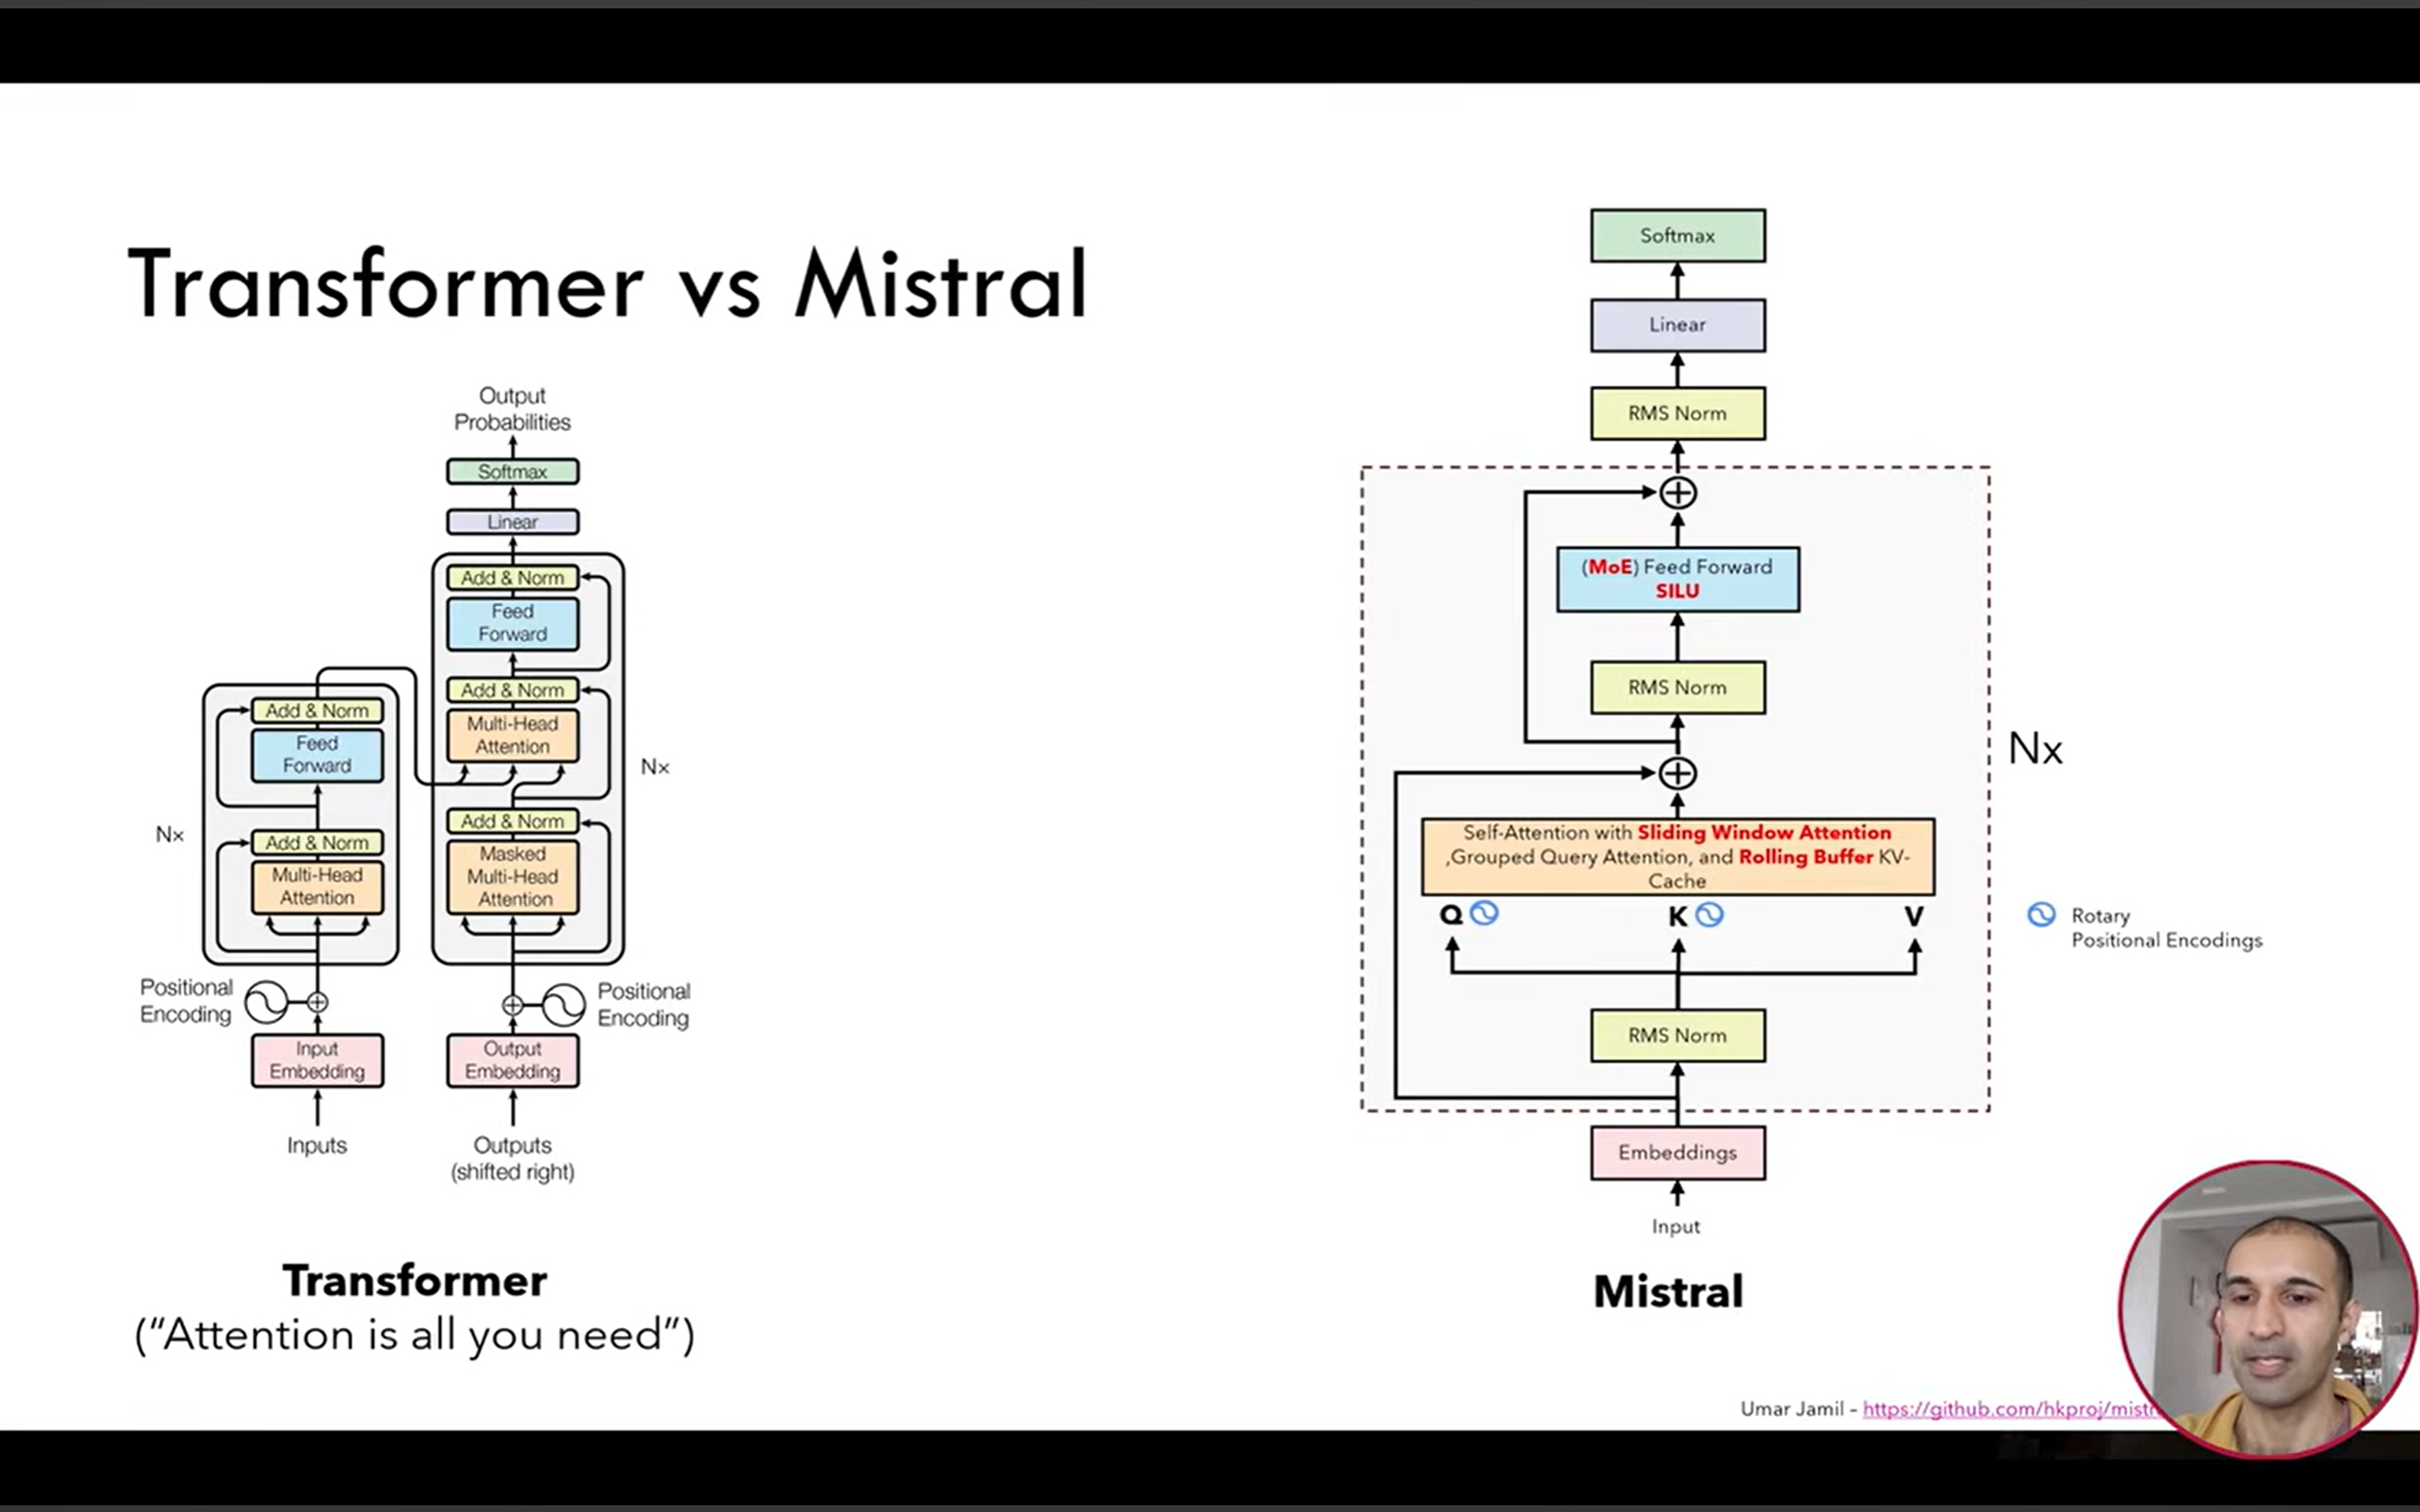

In [14]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\transformer_vs_mistral.png")
displayPNGImage(img_path)

# Sliding Window Attention and Rolling Buffer KV Cache

> **Source:** Mistral 7B paper — Jiang et al., 2023
> **Builds on:** Standard attention (O(N²) cost), KV cache (memory grows with sequence length)
> **Problem they solve:** Standard attention computes scores between every pair of tokens — cost grows quadratically with sequence length. The KV cache that stores past tokens grows linearly and never stops. For long sequences both become prohibitive. Sliding Window Attention and Rolling Buffer KV Cache are Mistral's two-part answer to this.

---

## Part 1 — Sliding Window Attention (SWA)

### The Problem with Full Attention on Long Sequences

In standard attention every token attends to every other token:

$$\text{cost} = O(N^2 \cdot d)$$

For a sequence of $N = 32{,}000$ tokens that is over a billion attention score computations per layer. Memory for the attention matrix alone is $O(N^2)$. At long contexts this becomes the dominant bottleneck — slow, memory-hungry, and increasingly worse as sequence length grows.

Most of this computation is also arguably wasteful. In natural language, most of what a token needs to understand its meaning comes from its nearby context — the few sentences around it — not from tokens thousands of positions away.

### What Sliding Window Attention Does

Instead of attending to all previous tokens, each token attends only to the $W$ most recent tokens — its local window:

$$\text{token at position } i \text{ attends to positions } [i-W,\ i]$$

**Where:**
- $W$ — the window size, a fixed hyperparameter. In Mistral 7B, $W = 4096$
- Position $i - W$ — the oldest token in the window (furthest back a token can look)
- Position $i$ — the token itself (self-attention is always included)
- Tokens at positions $< i - W$ — receive zero attention weight; they are outside the window



In [15]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\swa_attention_mask.svg")
displayImage(img_path)

The cost drops from $O(N^2)$ to $O(N \cdot W)$ — linear in sequence length for a fixed window size.

### The Critical Question — What About Information Beyond the Window?

At first glance this seems to throw away all long-range context. A token at position 5000 cannot directly attend to position 1. But this is where the transformer's layered structure saves everything.

**Information propagates through layers.**

At layer 1, each token sees $W$ neighbors.
At layer 2, each token sees $W$ neighbors — but those neighbors already contain information from *their* $W$ neighbors at layer 1.
At layer $k$, each token has access to information from up to $k \times W$ positions back.

Formally, the hidden state $h_i^{(k)}$ at layer $k$, position $i$ has access to input tokens in the range:

$$[i - k \times W,\ i]$$

For Mistral 7B with $W = 4096$ and $k = 32$ layers:

$$\text{theoretical receptive field} = 32 \times 4096 = 131{,}072 \text{ tokens}$$

In [16]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\swa_receptive_field.svg")
displayImage(img_path)


This is **not** the same as direct attention to all those tokens. The information is compressed and transformed through intermediate layers — fine-grained token-level details from far back are not preserved exactly. But the high-level semantic information does propagate through, which is sufficient for most language understanding tasks.

The paper explicitly notes: *"tokens outside the sliding window still influence next word prediction"* — the window limits direct attention, not total information flow.

---

### Attention Mask Comparison

In standard causal attention the mask is lower-triangular — every token attends to all previous tokens:

```
Standard causal mask (4 tokens):

       t1  t2  t3  t4
t1  [  1   0   0   0  ]
t2  [  1   1   0   0  ]
t3  [  1   1   1   0  ]
t4  [  1   1   1   1  ]
```

In sliding window attention with $W = 2$ the mask is a banded lower-triangular — each token attends only to itself and $W-1$ previous tokens:

```
SWA mask (4 tokens, W=2):

       t1  t2  t3  t4
t1  [  1   0   0   0  ]
t2  [  1   1   0   0  ]
t3  [  0   1   1   0  ]
t4  [  0   0   1   1  ]
```

Token $t4$ cannot see $t1$ or $t2$ — they are outside the window. This is the `-∞` mask applied to those positions before softmax, identical in mechanism to causal masking but with an additional left boundary.

---

### Speed in Practice

The paper reports that with $W = 4096$ on sequences of length 16,384, modifications to FlashAttention and xFormers yield a **2× speed improvement** over vanilla attention. At a sequence length of 32,768 the memory savings are even more significant.

---

## Part 2 — Rolling Buffer KV Cache

### Why Standard KV Cache Breaks Under SWA

Recall from KV cache notes: the cache stores all past K and V vectors, growing indefinitely:

```
After token 1:   cache size = 1
After token 2:   cache size = 2
After token N:   cache size = N   ← grows forever
```

But with SWA, each token only ever attends to the $W$ most recent tokens. Storing K and V vectors for tokens beyond $W$ positions back is pointless — they will never be used again. Yet standard KV cache keeps them anyway, wasting memory.

### The Rolling Buffer Idea

Fix the cache at size $W$. Store the K and V vectors for token at position $i$ at cache slot:

$$\text{slot}(i) = i \bmod W$$

**Where:**
- $i$ — the absolute position of the token in the sequence (0-indexed)
- $W$ — the window size (and cache size)
- $\bmod$ — the modulo operation: the remainder when dividing $i$ by $W$
- $\text{slot}(i)$ — which position in the fixed-size cache this token's K/V vectors occupy

When $i \geq W$, the modulo wraps around and the new token overwrites the oldest token in the cache — the one that just fell outside the attention window anyway.

In [17]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\rolling_buffer_kv_cache.svg")
displayImage(img_path)


### Concrete Example ($W = 4$)

| Step | Token position $i$ | Slot = $i \bmod 4$ | Cache contents (slots 0–3) |
|---|---|---|---|
| 1 | 0 | 0 | [t0, —, —, —] |
| 2 | 1 | 1 | [t0, t1, —, —] |
| 3 | 2 | 2 | [t0, t1, t2, —] |
| 4 | 3 | 3 | [t0, t1, t2, t3] — full |
| 5 | 4 | 0 | [**t4**, t1, t2, t3] — t0 overwritten |
| 6 | 5 | 1 | [t4, **t5**, t2, t3] — t1 overwritten |
| 7 | 6 | 2 | [t4, t5, **t6**, t3] — t2 overwritten |
| 8 | 7 | 3 | [t4, t5, t6, **t7**] — t3 overwritten |

The overwritten tokens (t0 at step 5, t1 at step 6, etc.) are exactly the tokens that would have fallen outside the sliding window — they are no longer needed by any future attention computation.

### Memory Savings

Standard KV cache for a sequence of $N$ tokens: size $= N$, grows forever.
Rolling buffer cache: size $= W$ always, stops growing once the cache is full.

From the paper: on a sequence length of 32,768 tokens with $W = 4096$, the rolling buffer reduces **cache memory by 8×**.

For Mistral 7B specifically with $W = 4096$, at sequence length 8,192 the cache memory is halved compared to standard KV cache — without any impact on model quality, because the discarded tokens were outside the attention window anyway.

---

## Part 3 — Pre-fill and Chunking

These are two inference-time optimizations that work alongside SWA and rolling buffer.

### Pre-fill

When generating a response, the prompt is known in full before generation starts. Rather than processing the prompt token by token (which would be slow), the entire prompt is processed in one forward pass to populate the KV cache:

```
Standard generation:
  token 1 → generate t2
  token 1, 2 → generate t3
  ...   ← redundant recomputation of prompt tokens

Pre-fill:
  process all prompt tokens at once → fill KV cache
  then generate t_{n+1}, t_{n+2}, ...  ← only new tokens computed
```

This eliminates redundant recomputation of the static prompt and is straightforward when the prompt fits within the window size $W$.

### Chunking

When the prompt is longer than $W$, it cannot be pre-filled in one pass — it would exceed the cache size. Chunking divides the prompt into segments of size $W$ and processes them sequentially:

```
Prompt of length 3W:
  Chunk 1: tokens [0, W)   → fill cache, compute attention
  Chunk 2: tokens [W, 2W)  → update cache, compute attention over chunk + cache
  Chunk 3: tokens [2W, 3W) → update cache, compute attention over chunk + cache
```

For each chunk, attention is computed over both the current chunk and whatever is in the rolling buffer cache from the previous chunk. This keeps memory usage bounded at $O(W)$ regardless of prompt length.

In [18]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\prefill_chunking.svg")
displayImage(img_path)

## How SWA and Rolling Buffer Work Together

They are designed as a pair — neither makes full sense without the other:

```
SWA:             each token attends to only W past tokens
                       ↓
Rolling buffer:  therefore only store W past K/V vectors
                       ↓
Result:          cache size is fixed at W, never grows
```

If you used SWA without rolling buffer, your cache would still grow to $N$ — storing K/V vectors you will never use again. If you used rolling buffer without SWA, you would be discarding K/V vectors that attention still needs. The two are mathematically coupled: rolling buffer is the correct and minimal KV cache for SWA.

---

## Limitations

**Hard attention cutoff.** Tokens more than $W$ positions back cannot be directly attended to at a given layer, even if they are highly relevant. Information propagates through layers but is transformed and compressed — exact token-level information from far back is not preserved. This can hurt tasks that require precise retrieval of specific tokens from long ago.

**Fixed window is not adaptive.** The window size $W$ is a hyperparameter fixed at training time. Every attention head at every layer uses the same window. Some heads might benefit from a wider view, others from a narrower one — SWA cannot express this. Approaches like Longformer use a mix of local and global attention to address this.

**Rolling buffer complicates some inference optimizations.** The circular buffer structure (slots assigned by $i \bmod W$) means the cache is not stored in sequence order. Techniques like speculative decoding, which assume straightforward sequential KV cache access, require modification to work correctly with the circular indexing.

**Theoretical vs effective receptive field.** The $k \times W$ receptive field at layer $k$ is a theoretical upper bound. In practice, information from tokens at the far edge of this range is heavily diluted by $k$ rounds of compression through the FFN and attention layers. The effective range over which precise information is preserved is much shorter.

## Mixture Of Experts

# Mixture of Experts — Core Concepts

> **Source:** Mixtral 8x7B paper — Jiang et al., 2024 (Mistral AI)
> **Context:** Mixtral replaces the dense FFN in every transformer block with a Mixture of Experts (MoE) layer. Instead of one FFN processing every token, multiple FFN networks (experts) exist and only a small subset activates per token. This section covers four interconnected concepts: how tokens are routed to experts, why routing alone causes collapse, how expert capacity prevents hardware issues, and what sparse vs active parameters actually means.

---

## 1. Top-K Routing — How Tokens Get Assigned to Experts

### Dense vs MoE — The Core Structural Difference

In a standard transformer every token passes through the same FFN at every layer. Every parameter does work for every token. This is a **dense** model.

In an MoE transformer the FFN is replaced by $N$ expert FFNs and a small learned router. For each token, the router selects only $K$ experts to run. The rest are completely skipped.

In [19]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\moe_dense_vs_moe.svg")
displayImage(img_path)


### The Router Mechanism

The router is a single linear layer with weight matrix $W_r \in \mathbb{R}^{d \times N}$, where $d$ is the token dimension and $N$ is the number of experts.

**Where:**
- $\mathbf{x} \in \mathbb{R}^d$ — the token representation entering the MoE layer
- $W_r$ — the learned router weight matrix, one column per expert
- $N$ — total number of experts (8 in Mixtral 8x7B)
- $K$ — number of experts selected per token (2 in Mixtral 8x7B)

**Step 1 — Compute a score for every expert:**

$$s_i = \mathbf{x} \cdot \mathbf{w}_{r,i} \quad \text{for } i = 1, \ldots, N$$

Each score $s_i$ measures how relevant expert $i$ is for this particular token.

**Step 2 — Convert to probabilities via softmax:**

$$p_i = \frac{e^{s_i}}{\sum_{j=1}^{N} e^{s_j}}$$

**Step 3 — Keep only the top-K probabilities, zero out the rest:**

$$\tilde{p}_i = \begin{cases} p_i & \text{if } i \in \text{top-}K(\{p_1, \ldots, p_N\}) \\ 0 & \text{otherwise} \end{cases}$$

**Step 4 — Renormalize the kept scores so they sum to 1:**

$$g_i = \frac{\tilde{p}_i}{\sum_{j} \tilde{p}_j}$$

**Step 5 — Compute output as weighted sum of selected experts:**

$$\text{output} = \sum_{i=1}^{N} g_i \cdot \text{Expert}_i(\mathbf{x})$$

Only $K$ experts actually run — the others contribute zero and are never computed.

In [20]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\moe_router_topk.svg")
displayImage(img_path)


### Why K=2 and Not K=1 or K=All

**K=1 (hard routing):** Only one expert gets gradient signal per token. Experts that are not selected train very slowly. Training becomes unstable and expert collapse occurs faster.

**K=N (all experts):** Every expert runs every token. No compute savings — you built a larger dense FFN.

**K=2:** Two experts provide enough gradient diversity that all experts receive training signal. The output blends two expert perspectives. At K=2 with N=8, only 25% of expert parameters activate per token — the compute savings are large while quality remains high.

### What "Batch of Tokens" Means for Routing

An important clarification: the batch dispatched to experts during training contains tokens from **multiple sequences**, not just one. All sequences in a training batch are flattened — tokens from different sentences, documents, and tasks are mixed together and each receives an independent routing decision.

This matters because similar tokens across different sequences cluster at the same experts. Tokens about code from sequence 1 and sequence 7 may both route to expert 3. This clustering is what causes load imbalance even when training looks balanced on average.

---

## 2. Expert Collapse and Auxiliary Loss

### The Collapse Problem

If you train an MoE model with top-K routing and no other constraint, a self-reinforcing feedback loop emerges within the first few thousand steps:

```
some experts get slightly better outputs by chance
→ router sends more tokens to those experts
→ those experts train more and improve further
→ router sends even more tokens to them
→ repeat until 1-2 experts handle everything
```

The result: you built 8 experts but effectively use 1–2. You pay the memory cost of 8 experts and get the quality of 1. This is called **expert collapse** or **load imbalance**.

In [21]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\moe_collapse_vs_balanced.svg")
displayImage(img_path)


### The Intuition for the Fix

You want to penalize the router whenever it sends too many tokens to some experts and too few to others. The penalty needs to:
1. Be differentiable so it can be backpropagated into the router weights
2. Scale with how severe the imbalance is
3. Not override the main language modeling objective

### The Auxiliary Load Balancing Loss

For each expert $i$, define two quantities computed over a batch of $T$ tokens:

**$f_i$ — fraction of tokens actually routed to expert $i$:**

$$f_i = \frac{1}{T} \sum_{t=1}^{T} \mathbf{1}[\text{token } t \text{ selects expert } i]$$

$f_i$ is a hard count — how many tokens truly went to expert $i$. It is not differentiable.

**$P_i$ — mean routing probability assigned to expert $i$:**

$$P_i = \frac{1}{T} \sum_{t=1}^{T} p_i^{(t)}$$

$P_i$ is the average softmax probability the router gave to expert $i$ across all tokens. This is differentiable — gradients flow through $p_i^{(t)}$.

**The auxiliary loss:**

$$\mathcal{L}_{\text{aux}} = N \cdot \sum_{i=1}^{N} f_i \cdot P_i$$

**Why $f_i \times P_i$ creates the right signal:**

$f_i$ is large when expert $i$ already receives many tokens. $P_i$ is large when the router is still assigning high probability to expert $i$. Multiplying them means the loss is largest when an overloaded expert is still being favored by the router. Backpropagating through $P_i$ pushes the router to lower its scores for overloaded experts and raise them for underloaded ones. Since $f_i$ is not differentiable, it acts as a weighting factor — it tells the gradient where to push without being updated itself.

The $N$ scaling factor keeps the loss magnitude consistent regardless of how many experts exist.

**Combined with the main objective:**

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{LM}} + \alpha \cdot \mathcal{L}_{\text{aux}}$$

$\alpha$ is typically 0.01 to 0.001 — small enough that the router does not sacrifice language modeling quality just to balance load, but large enough to prevent collapse.

### What Balanced Load Looks Like

With K=2 and N=8 experts, if load were perfectly balanced each expert would receive exactly $\frac{K}{N} = \frac{2}{8} = 25\%$ of all tokens. The auxiliary loss does not enforce perfect balance — it prevents extreme concentration. Some natural specialization remains and is desirable.

---

## 3. Expert Capacity and Token Overflow

### Why a Fixed Capacity Is Needed

MoE models distribute experts across multiple GPUs. Tokens are dispatched to their assigned experts in parallel — all GPUs process their assigned tokens simultaneously and synchronize results. For this parallel dispatch to work efficiently on hardware, each expert must process a **fixed-size block of tokens**. GPUs cannot efficiently handle variable-length inputs across devices.

This forces a design constraint: every expert is assigned a fixed buffer of size $C$ — the **expert capacity** — which is the maximum number of tokens it will process in one forward pass, regardless of how many tokens the router actually sends to it.

### The Capacity Formula

$$C = \left\lfloor \frac{T \times K}{N} \times \text{cf} \right\rfloor$$

**Where:**
- $T$ — total tokens in the batch
- $K$ — experts selected per token
- $N$ — number of experts
- $\text{cf}$ — capacity factor (hyperparameter, typically 1.0–2.0)
- $\lfloor \cdot \rfloor$ — floor (round down to integer)

**Building the intuition:**

$T \times K$ is the total number of expert slots needed — every token needs $K$ assignments. Dividing by $N$ gives the perfectly balanced average: how many tokens each expert would receive if load were exactly equal. The capacity factor $\text{cf}$ scales this average up as a safety buffer.

**Concrete example:**

$T = 512$, $K = 2$, $N = 8$, $\text{cf} = 1.25$:

$$C = \left\lfloor \frac{512 \times 2}{8} \times 1.25 \right\rfloor = \left\lfloor 128 \times 1.25 \right\rfloor = 160 \text{ tokens per expert}$$

On a perfectly balanced batch each expert receives 128 tokens. The extra 32 slots are the safety margin for natural imbalance.

### Token Overflow — What Happens When Capacity Is Exceeded

When more tokens arrive at an expert than its capacity $C$ allows, the excess tokens are **dropped** — they skip that expert entirely for that layer.

The dropped tokens are not zeroed out. They continue through the transformer via the residual connection, carrying their unchanged representation from the previous layer. If K=2, a token dropped from one expert may still be processed by its second assigned expert.

In [22]:
img_path = os.path.join(notebook_dir, r"assets\06_llm_arch_com\moe_capacity_overflow.svg")
displayImage(img_path)


### Hand Calculation — Capacity and Overflow Together

**Setup:** $T=12$, $K=2$, $N=4$, $\text{cf}=1.0$

$$C = \left\lfloor \frac{12 \times 2}{4} \times 1.0 \right\rfloor = 6 \text{ tokens per expert}$$

Router assigns (top-2 per token):

| Token | Expert 1 | Expert 2 | Expert 3 | Expert 4 |
|---|---|---|---|---|
| t1 | ✓ | ✓ | | |
| t2 | ✓ | | ✓ | |
| t3 | | ✓ | | ✓ |
| t4 | ✓ | ✓ | | |
| t5 | ✓ | | ✓ | |
| t6 | | ✓ | | ✓ |
| t7 | ✓ | ✓ | | |
| t8 | ✓ | | | ✓ |
| t9 | ✓ | ✓ | | |
| t10 | | | ✓ | ✓ |
| t11 | ✓ | | ✓ | |
| t12 | | ✓ | | ✓ |

Token counts per expert: Expert 1 = **8**, Expert 2 = **7**, Expert 3 = 4, Expert 4 = 5

Capacity is 6. Experts 1 and 2 overflow:

```
Expert 1: accepts t1,t2,t4,t5,t7,t8 → DROPS t9, t11
Expert 2: accepts t1,t3,t4,t6,t7,t9 → DROPS t12
Expert 3: accepts t2,t5,t10,t11     → no overflow
Expert 4: accepts t3,t6,t8,t10,t12  → no overflow
```

What dropped tokens still receive:
- t9: dropped from expert 1, still processed by expert 2 ✓
- t11: dropped from expert 1, still processed by expert 3 ✓
- t12: dropped from expert 2, still processed by expert 4 ✓

In this case all dropped tokens still have their second expert. In a worse scenario both assigned experts are overloaded — the token bypasses the MoE layer entirely via residual.

### The Capacity Factor Tradeoff

| cf value | Buffer | Overflow risk | Wasted compute | Quality |
|---|---|---|---|---|
| 1.0 | None | High | Low | Lower |
| 1.25 | 25% above average | Low | Moderate | Good |
| 1.5 | 50% above average | Very low | Higher | Better |
| 2.0 | 2× average | Minimal | High | Best |

Most practical MoE models use $\text{cf}$ between 1.25 and 1.5. At inference, the capacity constraint can often be relaxed or removed entirely since structured parallel dispatch is less critical.

---

## 4. Sparse vs Active Parameters

Total parameters and active parameters are two different numbers for MoE models, and confusing them causes most of the misunderstanding around MoE model sizes.

**Total parameters** — all weights across all experts, attention layers, and embeddings. Determines memory cost. All experts must be resident in memory because you do not know which tokens will activate which experts until the router runs.

**Active parameters** — the subset of weights that compute something for one token in one forward pass. Determines compute cost (FLOPs, latency, energy).

For Mixtral 8x7B with K=2, N=8:

```
Total parameters:   ~46.7B   (pay this in memory)
Active parameters:  ~12.9B   (pay this in compute per token)
```

The promise of MoE: **decouple model capacity from compute cost.** Doubling the number of experts doubles total parameters (more knowledge capacity) while keeping active parameters constant (same compute per token).

| | Dense 13B | Dense 47B | Mixtral 8x7B |
|---|---|---|---|
| Total parameters | 13B | 47B | 46.7B |
| Active per token | 13B | 47B | ~12.9B |
| Memory cost | Low | High | High |
| Compute per token | Low | High | Low |
| Quality | Medium | High | High |

The hidden costs: all experts must be in GPU memory simultaneously, communication overhead exists for dispatching tokens across devices, and load imbalance can reduce effective active parameters below the theoretical K × expert_params.

---

## How All Four Concepts Connect

```
Top-K routing selects K experts per token
         ↓
Without constraint → expert collapse (feedback loop)
         ↓
Auxiliary loss penalizes imbalance → balanced routing
         ↓
Even balanced routing has variance per batch
         ↓
Expert capacity provides fixed buffer C per expert
         ↓
Tokens beyond C are dropped (token overflow)
         ↓
cf trades overflow risk against wasted compute
         ↓
Result: sparse activation — only K/N parameters active per token
        total params (memory) ≠ active params (compute)
```